# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measurements from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, create a new dataframe `d1` that only includes the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [12]:
library(tidyverse)

getwd()
setwd('/Users/tamarjaparidze/Documents/DataSciencePsychNeuro/Exercise datasets/hcp_data')
all_data <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")
#head(all_data,10)

d1 <- all_data %>% #select desired columns
  select(Subject, Gender, Flanker_Unadj, FS_IntraCranial_Vol, FS_Tot_WM_Vol, FS_Total_GM_Vol)

d1 <- drop_na(d1) #remove all NAs

head(d1,10) 

[1] "/Users/tamarjaparidze/Documents/DataSciencePsychNeuro/Exercise datasets/hcp_data"

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024
7,101309,M,113.67,1540433,491221,707674
8,101410,M,108.46,1824028,502143,773472
9,101915,F,98.94,1485035,405886,676282


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

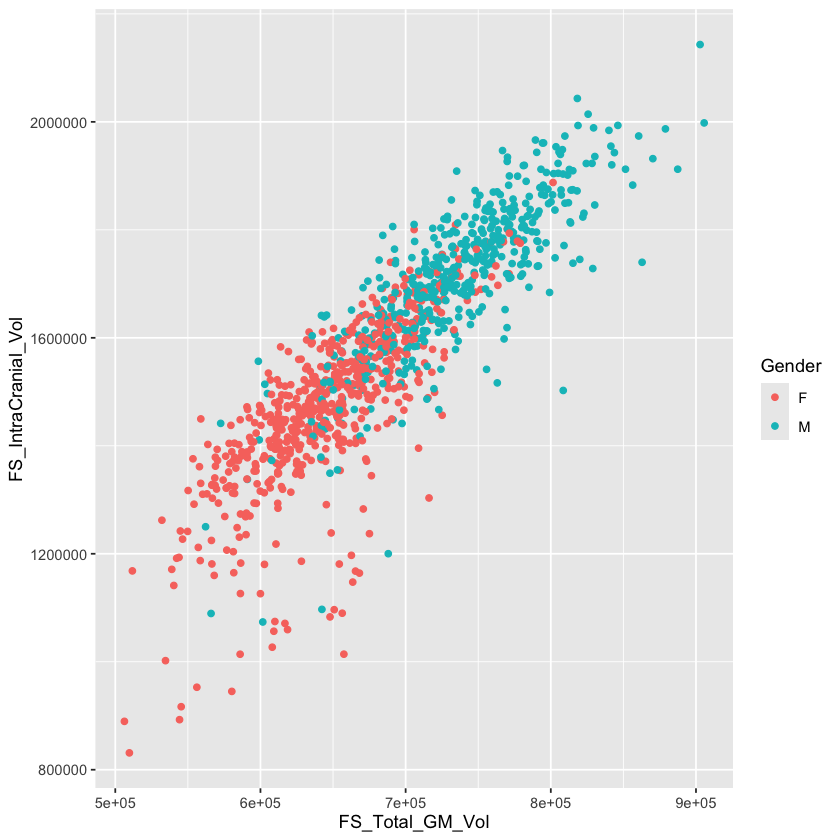

In [13]:
library(ggplot2)
ggplot(data = d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender)) +
  geom_point()


What patterns do you observe in the scatter plot?

> * There is a strong correlation between intracranial and gray matter volume overall.
> * Men have higher intracranial and gray matter volume than women.
> * Compared to the main clustered line and an imagined line of fit there, women's gray matter and intracranial volume distribution seems to have a higher mean squared error, with more women exhibiting lower intracranial volume than would be expected by their gray matter volume.

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logistic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [19]:
#str(d1$Gender)
d1$Gender <- as.factor(d1$Gender)

log_model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                 family = "binomial", 
                 data = d1)

summary(log_model)


Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = "binomial", data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are significantly associated with gender?

> Total Gray Matter volume and total intracranial volume, but not total white matter volume.

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [40]:
#to divide into the training and testing sets, I will retrain the model on only the training subset of the data 
dim(d1)
set.seed(2023)

#pull random sample of 30% of row indices
test.inds <- sample(1:nrow(d1), nrow(d1)*0.3)
test_set <- cbind(d1$FS_Tot_WM_Vol[test.inds], d1$FS_Tot_GM_Vol[test.inds], d1$FS_IntraCranial_Vol[test.inds])
dim(test_set)
train_set <- cbind(d1$FS_Tot_WM_Vol[-test.inds], d1$FS_Tot_GM_Vol[-test.inds], d1$FS_IntraCranial_Vol[-test.inds])
dim(train_set)
#Tamar: I didn't finish this part

#for full model: 
probs <- predict(log_model, type="response")
preds <- ifelse(probs > 0.5, "M", "F")
fullmodel_acc = mean(preds==d1$Gender)
print(fullmodel_acc)

[1] 1113    6

[1] 333   2

[1] 780   2

[1] 0.8203055


What is the prediction accuracy for gender from the full model?

>*It is 82%

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence interval for your model's prediction accuracy. Plot a histogram of the bootstrapped accuracies, and estimate the confidence interval using the standard deviation of the bootstrap distribution.


In [46]:
# The function needs two inputs: Data, Index
library(boot)

boot.fn <- function(data, index){  
    # return: throw this as output
    # coef: extract coefficients from model object 
    model = glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                 family = "binomial", 
                 data = data,
                 subset = index)
    probs <- predict(model, type="response")
    preds <- ifelse(probs > 0.5, "M", "F")
    model_acc = mean(preds==d1$Gender)
    return(model_acc)
}

print(boot.fn(d1, 1:nrow(d1)))        

boot_obj = boot(d1 ,boot.fn ,R=1000) #R=repetitions 
print(boot_obj)

attributes(boot_obj) #get all attributes of the boot object 

hist(boot(d1, boot.fn ,R=1000))$t[,2]


[1] 0.8203055

ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = d1, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
     original     bias    std. error
t1* 0.8203055 -0.3147251  0.01513438


$names
 [1] "t0"        "t"         "R"         "data"      "seed"      "statistic"
 [7] "sim"       "call"      "stype"     "strata"    "weights"  

$class
[1] "boot"

$boot_type
[1] "boot"

ERROR: Error in hist.default(boot(d1, boot.fn, R = 1000)): 'x' must be numeric


How robust is the prediction accuracy of the full model?

> In the boostrapping histograms, the confidence interval for Total White Matter volume includes 0, but the confidence intervals for total GM volume and intracranial volume do not. These findings reject the H0 for GM and intracranial volume, with the H0 being that there is no relationship between these measures and gender. These findings align with the predictions from the logistic model above.  

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted) model with the distribution of accuracies obtained when the grey matter volume variable is permuted, using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

In [47]:
# First let's make a copy of the data set that we'll keep permuting
permd1 = d1 #want to preserve the non-permuted, true form of data!

# Set the number of iterations
R=1000

# Next smake an output object to store the results
perm.accs=matrix(NA,nrow=R, ncol=4) #filling with nas at first

# Now just write a for loop where we scramble the observations
# in X using the sample() function. We'll scramble the observations in R different ways
for (i in 1:R){
  permd1$FS_Total_GM_Vol=d1$FS_Total_GM_Vol[sample(nrow(d1))]
  perm_model=(glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                 family = "binomial", 
                 data = permd1))
  probs <- predict(perm_model, type="response")
  preds <- ifelse(probs > 0.5, "M", "F")
  perm.accs[i] = mean(preds==permd1$Gender) 

    }

hist(perm.accs[,3])


ERROR: Error in hist.default(perm.accs[, 3]): invalid number of 'breaks'


How much does the grey matter volume influence the prediction accuracy of the model?

> *Write your response here*
>

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and explain when each is appropriate.

> *Write your response here*
>

**DUE:** 11:59pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** I used chatGPT for debugging and syntax help, but clearly it did not help. Soeme of my prompts included asking how to treat the Gender (outcome) variable as factors (0 and 1), and how to get prediction accuracy after running the glm model. 